In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [18]:
df = pd.read_csv("../data/base_tratada_final.csv")

In [19]:
# Verificação inicial
print(f"Dataset carregado com {df.shape[0]} transações e {df.shape[1]} colunas.")
df.info()

Dataset carregado com 10000 transações e 14 colunas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Valor              10000 non-null  float64
 1   TipoChave          10000 non-null  object 
 2   Status             10000 non-null  object 
 3   Anomalia           10000 non-null  int64  
 4   Hora               10000 non-null  int64  
 5   DiaDaSemana        10000 non-null  int64  
 6   FimDeSemana        10000 non-null  int64  
 7   Dia_do_Mes         10000 non-null  int64  
 8   Horario_Comercial  10000 non-null  int64  
 9   Madrugada          10000 non-null  int64  
 10  Dia_de_Pagamento   10000 non-null  int64  
 11  Valor_Redondo      10000 non-null  int64  
 12  Status_Pendente    10000 non-null  int64  
 13  Mesmo_Banco        10000 non-null  int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 1.1+ MB


C:\Users\augus\AppData\Local\Temp\ipykernel_32172\3452801828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anomalia', data=df, palette='viridis')


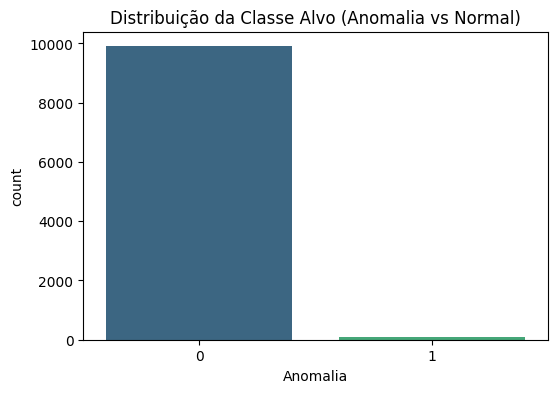

Anomalia
0    99.0
1     1.0
Name: proportion, dtype: float64


In [20]:
# Analisando a proporção de anomalias
plt.figure(figsize=(6, 4))
sns.countplot(x='Anomalia', data=df, palette='viridis')
plt.title("Distribuição da Classe Alvo (Anomalia vs Normal)")
plt.show()

print(df['Anomalia'].value_counts(normalize=True) * 100)

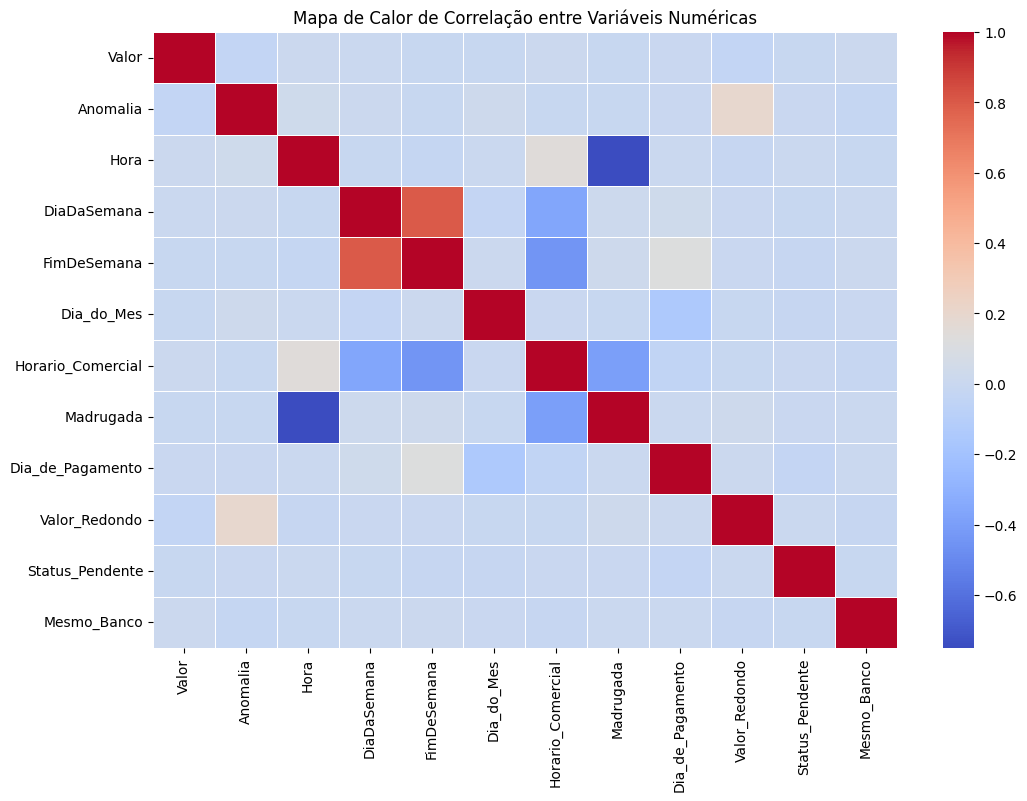

In [21]:
plt.figure(figsize=(12, 8))

# Selecionamos apenas colunas numéricas antes de rodar o .corr()
df_numerico = df.select_dtypes(include=[np.number])

correlation = df_numerico.corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlação entre Variáveis Numéricas")
plt.show()

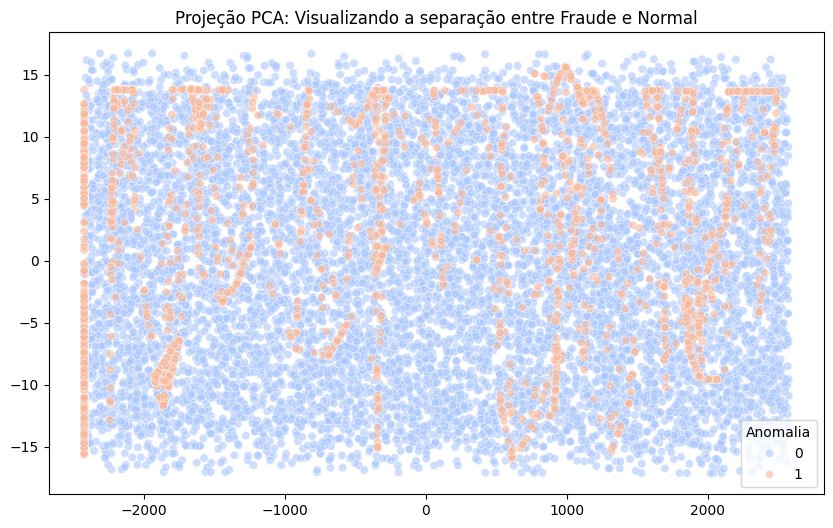

Variância explicada pelos 2 componentes: 100.00%


In [22]:
# Definindo as colunas de forma explícita
# Aqui eu rodo o SMOTE dnv pra n depender da outra celula 
cols_num = ['Valor', 'Hora', 'Dia_do_Mes', 'DiaDaSemana', 'FimDeSemana', 'Horario_Comercial']
cols_cat = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'TipoChave', 'Status']

# Configurando o Preprocessor 
# Usamos o 'handle_unknown=ignore' para não quebrar se algo novo aparecer
preprocessor = ColumnTransformer([
    ('num', 'passthrough', cols_num), 
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cols_cat)
])

X = df[cols_num + cols_cat] 
y = df['Anomalia']

# Aplicando o preprocessor ANTES do SMOTE (precisa de dados puramente numéricos)
X_processado = preprocessor.fit_transform(X)

# Agora rodamos o SMOTE na base já processada
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_res, y_res = smote.fit_resample(X_processado, y)

# Célula de Análise PCA

# Aplica o PCA para reduzir a 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_res) 

# Visualização 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_res, palette='coolwarm', alpha=0.6)
plt.title("Projeção PCA: Visualizando a separação entre Fraude e Normal")
plt.show()

# Explicação de quanto da informação original foi mantida
print(f"Variância explicada pelos 2 componentes: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

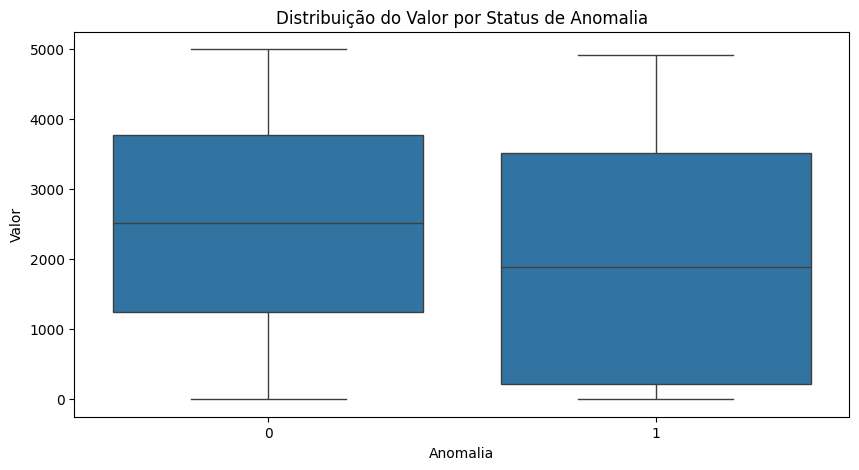

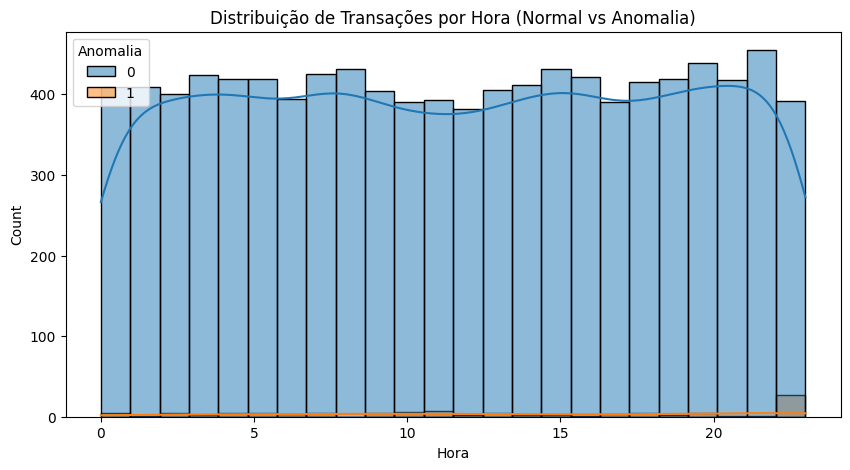

In [23]:
# Visualizando como as fraudes se concentram
plt.figure(figsize=(10, 5))
sns.boxplot(x='Anomalia', y='Valor', data=df)
plt.title("Distribuição do Valor por Status de Anomalia")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Hora', hue='Anomalia', kde=True, bins=24)
plt.title("Distribuição de Transações por Hora (Normal vs Anomalia)")
plt.show()

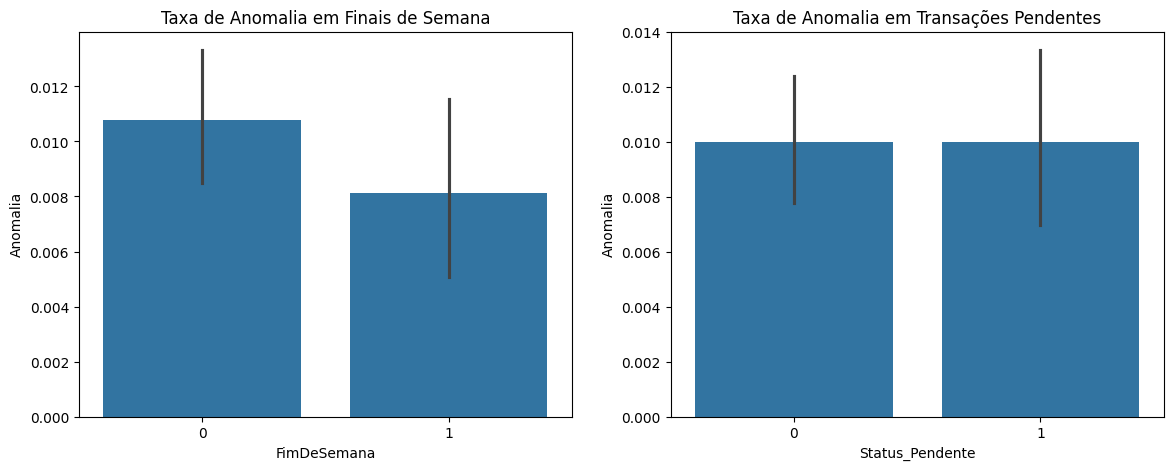

In [24]:
# Analisando flags como 'FimDeSemana' ou 'Status_Pendente'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='FimDeSemana', y='Anomalia', data=df, ax=axes[0])
axes[0].set_title("Taxa de Anomalia em Finais de Semana")

sns.barplot(x='Status_Pendente', y='Anomalia', data=df, ax=axes[1])
axes[1].set_title("Taxa de Anomalia em Transações Pendentes")
plt.show()

In [25]:
var_cat = [
    'Madrugada',
    'Dia_do_Mes',
    'Dia_de_Pagamento',
    'Valor_Redondo',
    'Status_Pendente',
    'Mesmo_Banco',
    'DiaDaSemana',
    'FimDeSemana',
    'Horario_Comercial',
    'TipoChave',
    'Status'
]

var_num = [
    'Valor', 'Hora'
]

var_ignored = [
    'EndToEndId',
    'DataHora_Tratada',
    'Anomalia'
]

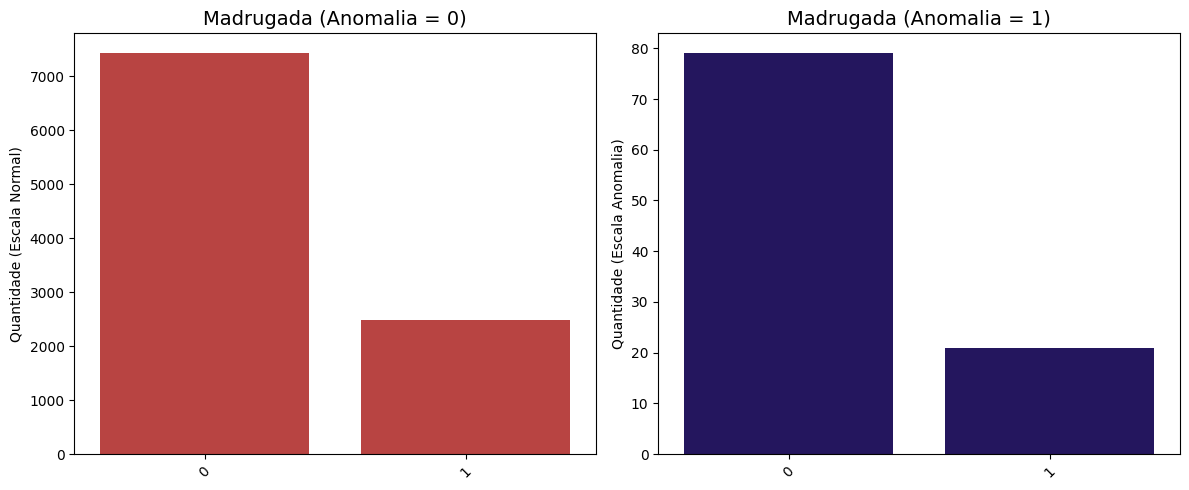

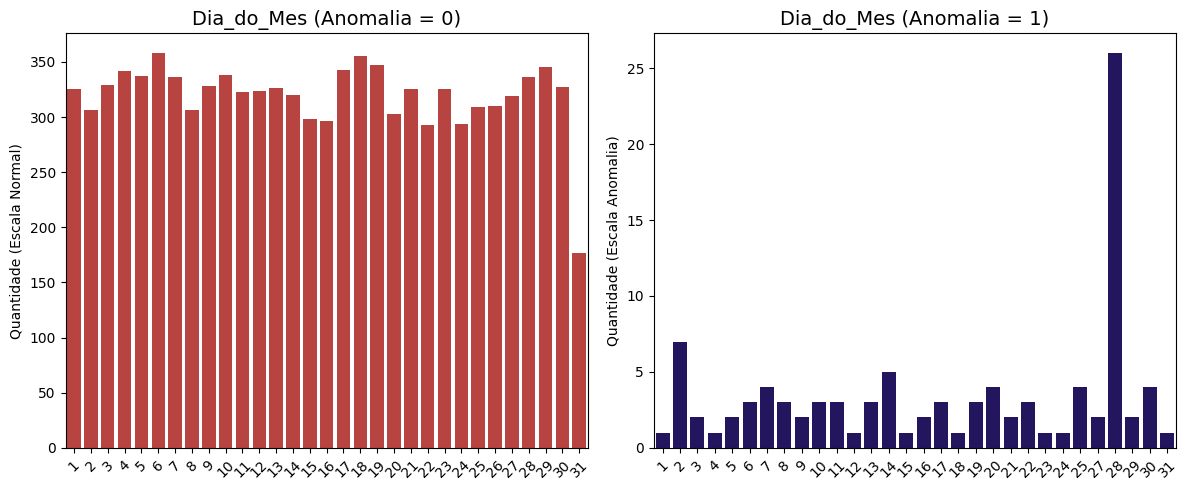

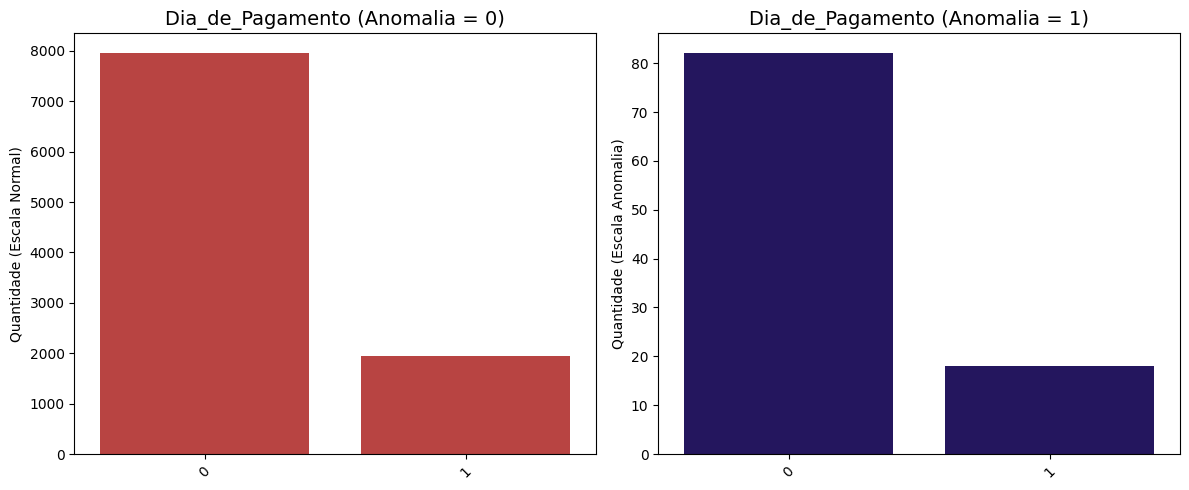

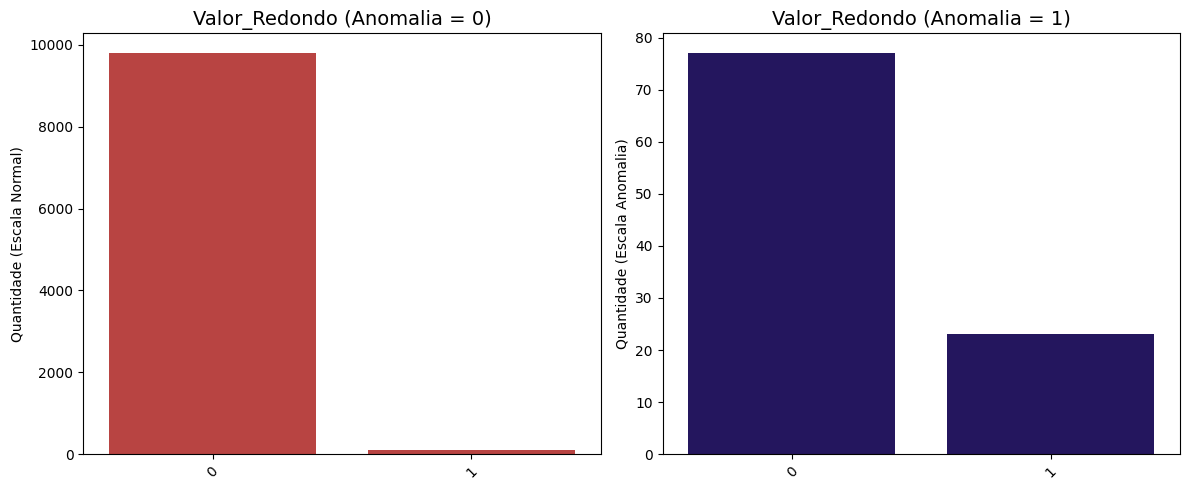

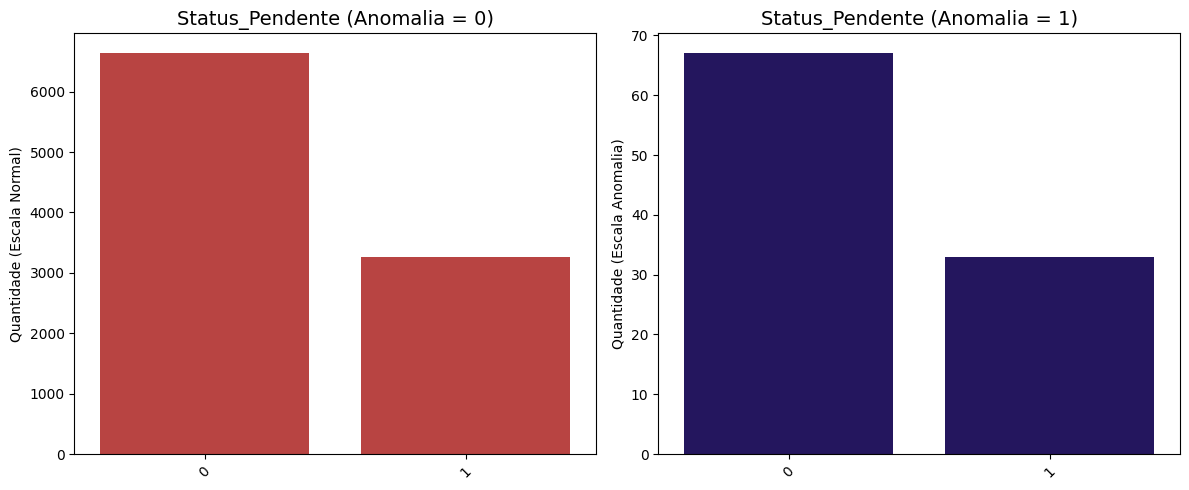

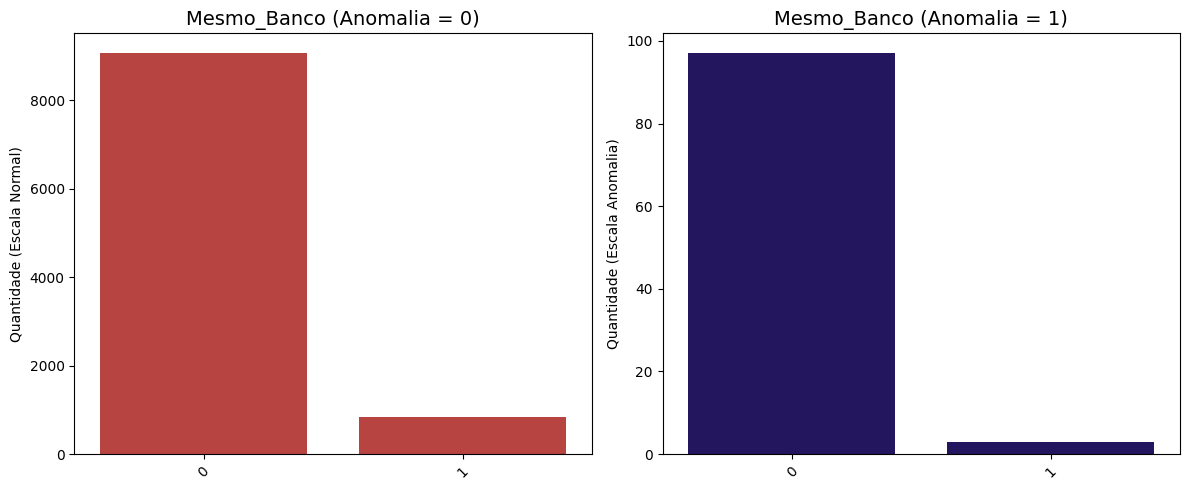

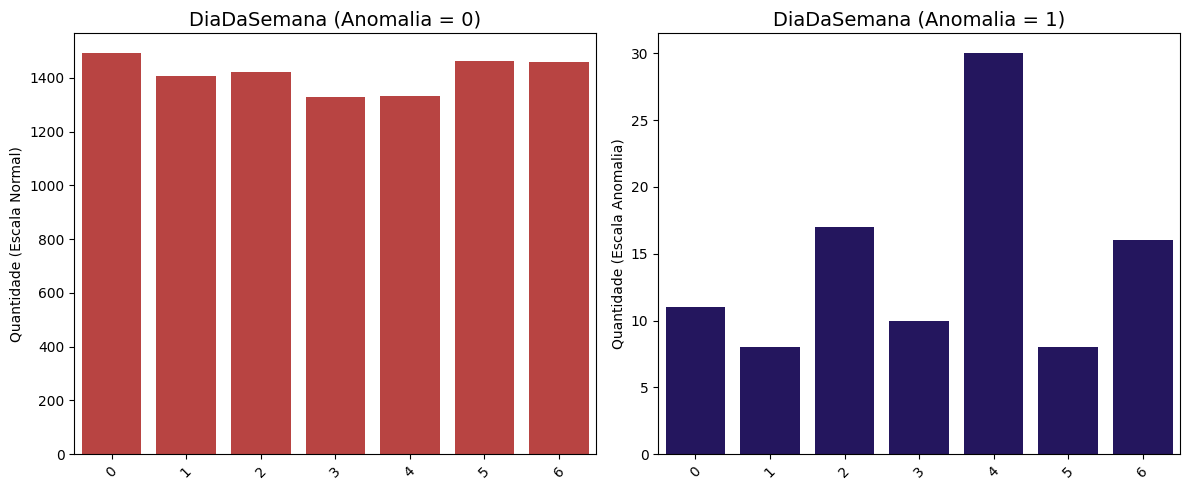

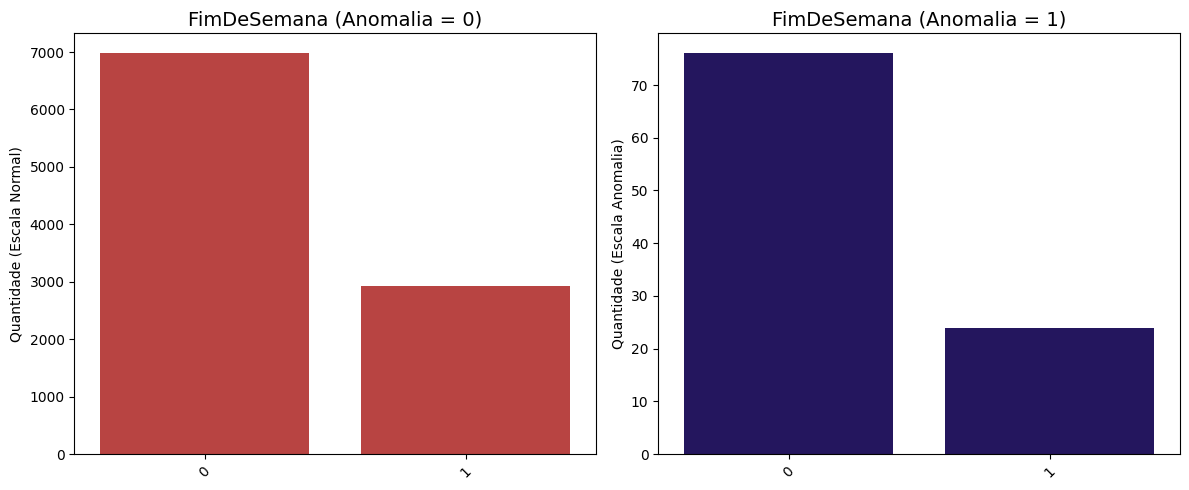

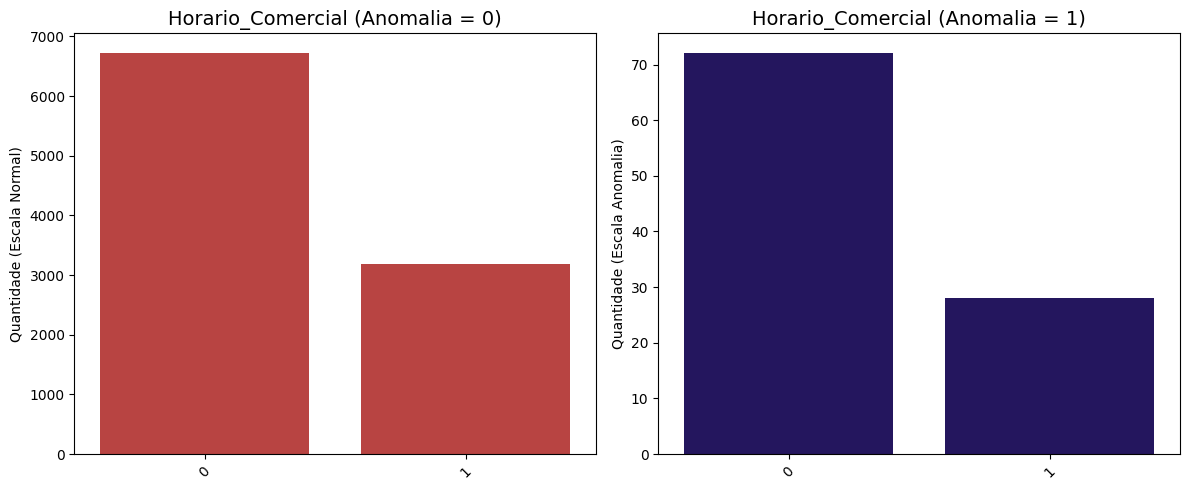

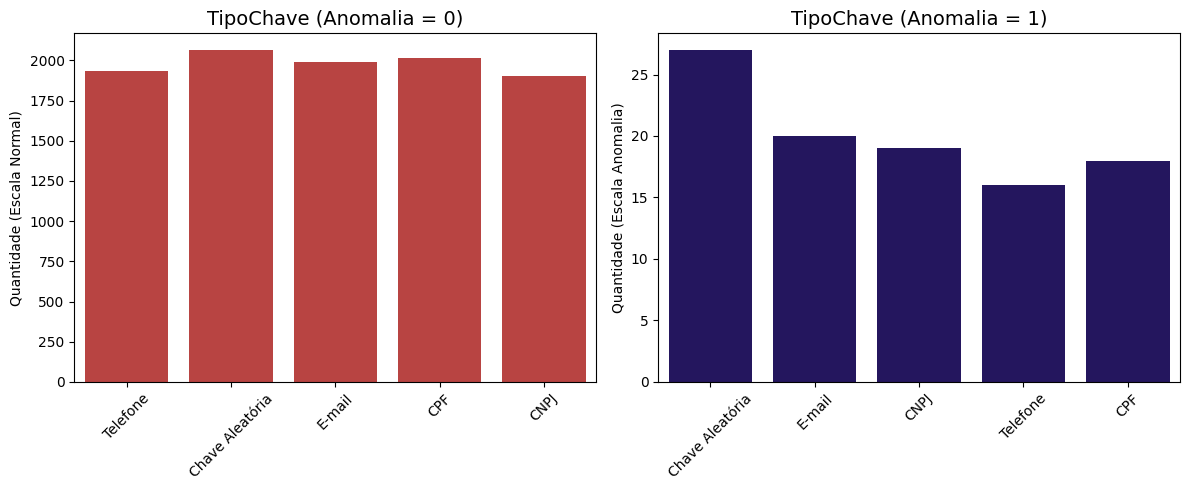

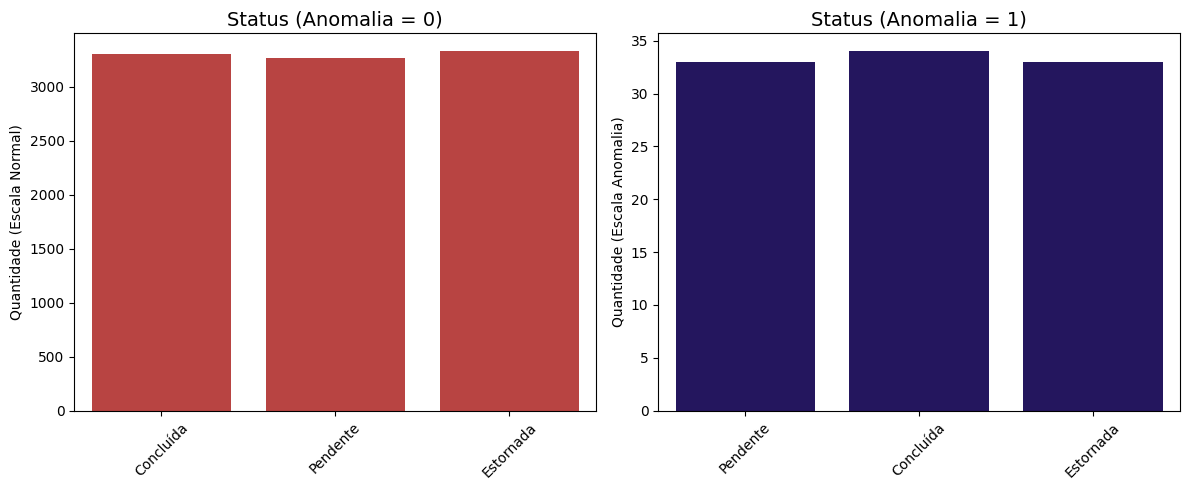

In [26]:
for coluna in var_cat:
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
    df_normal = df[df['Anomalia'] == 0]
    df_anomalo = df[df['Anomalia'] == 1]
    
    # --- GRÁFICO 1: ANOMALIA 0 (Esquerda) ---
    sns.countplot(
        data=df_normal, 
        x=coluna, 
        color="#cc312e", 
        ax=ax1           
    )
    ax1.set_title(f'{coluna} (Anomalia = 0)', fontsize=14)
    ax1.set_xlabel('')
    ax1.set_ylabel('Quantidade (Escala Normal)')
    ax1.tick_params(axis='x', rotation=45)
    
    # --- GRÁFICO 2: ANOMALIA 1 (Direita) ---
    sns.countplot(
        data=df_anomalo, 
        x=coluna, 
        color="#1d0a6a", 
        ax=ax2           
    )
    ax2.set_title(f'{coluna} (Anomalia = 1)', fontsize=14)
    ax2.set_xlabel('')
    ax2.set_ylabel('Quantidade (Escala Anomalia)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()